# What Makes a House More Expensive? A Machine Learning Approach

The goal of this project is to identify the key factors that drive residential property prices in California.

The central question this project aims to answer is:

* **What are the three main characteristics that most significantly drive house prices up?**

To answer this question, we follow a four-step approach. We begin with an exploratory data analysis to understand the distribution of each variable, detect patterns, and visualize relationships between features and price. We then focus on preparing the data by removing outliers and encoding categorical variables appropriately for the model. Next, we move to building the model by training a Random Forest Regressor optimized through GridSearchCV to ensure the best possible hyperparameters. Finally, we communicate the results by interpreting the feature importance scores extracted from the model to identify and rank the three characteristics that contribute the most to house price increases.

### 1. Exploratory Data Analysis

The dataset contains 545 observations and 13 variables. The target variable is price. See below the description of each feature :

  * Price : Sale price of the house
  * area : Total area of the house in square feet
  * bedrooms : Number of bedrooms
  * bathrooms	: Number of bathrooms
  * stories	: Number of floors
  * mainroad : Whether the house is connected to a main road
  * guestroom	: Whether the house has a guest room
  * basement : Whether the house has a basement
  * hotwaterheating	: Whether the house has a hot water heating system
  * airconditioning	: Whether the house has air conditioning
  * parking	: Number of parking spots available
  * prefarea : Whether the house is located in a preferred/prime neighborhood
  * furnishingstatus : Furnishing level of the house — furnished, semi-furnished, or unfurnished

In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# loading our dataset
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


From the information below, we can see that we dont have missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


**Price Range:** The property prices range from 1.75 million to 13.3 million, with an average price of approximately 4.77 million.

**Property Size:** The areas vary from 1,650 sq ft to 16,200 sq ft, with a mean area of around 5,150 sq ft, indicating a dataset with both small and very large properties.

**Bedrooms:** Most properties have 2 to 3 bedrooms, with the median being 3 bedrooms. The dataset includes homes with up to 6 bedrooms.

**Bathrooms:** The majority of homes have 1 bathroom, but some larger homes have up to 4 bathrooms, with an average of approximately 1.29 bathrooms.

**Stories:** Most buildings are 1 or 2 stories, with the maximum being 4 stories, and an average of 1.81 stories.

**Parking:** Parking availability varies, with 0 to 3 parking spots, and almost 70% of properties have no parking.

In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


The histogram below displays the distribution of price values across the dataset. The distribution is right-skewed (positively skewed), with the majority of prices concentrated between 2,000,000 and 6,000,000, peaking at approximately 3,000,000–4,000,000. The presence of a long right tail indicates that a small number of observations have significantly higher prices, reaching up to approximately 13,000,000. The KDE (Kernel Density Estimate) overlay confirms the non-normal, positively skewed nature of the distribution, suggesting that the mean is likely greater than the median.

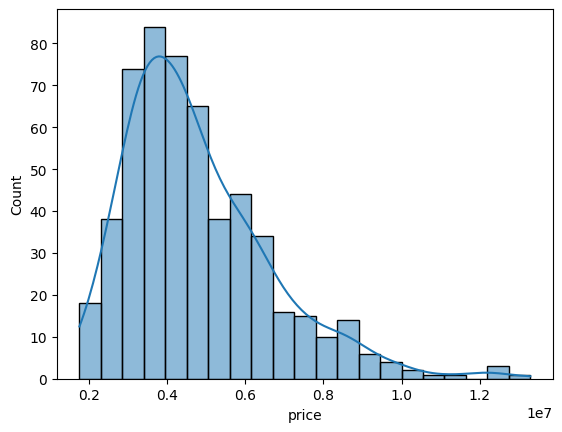

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["price"], kde=True)
plt.show()

Our boxplot confirms the presence of outliers

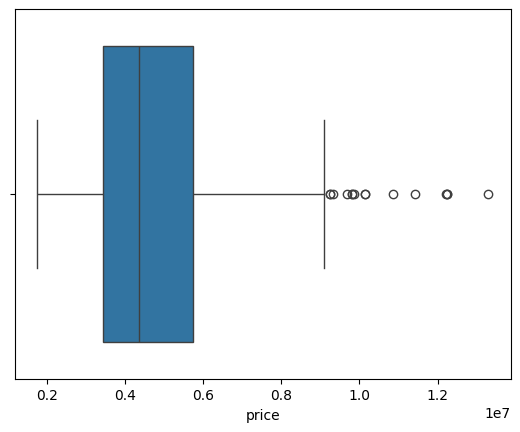

In [ ]:
sns.boxplot(x=df["price"])
plt.show()

The correlation heatmap shows that the highest correlations are between price and area (0.54), and price and bathrooms (0.52). All other variables have moderate to low correlations, mostly below 0.5. Therefore, there is no strong multicollinearity in the dataset, and the independent variables can be safely used in analysis.

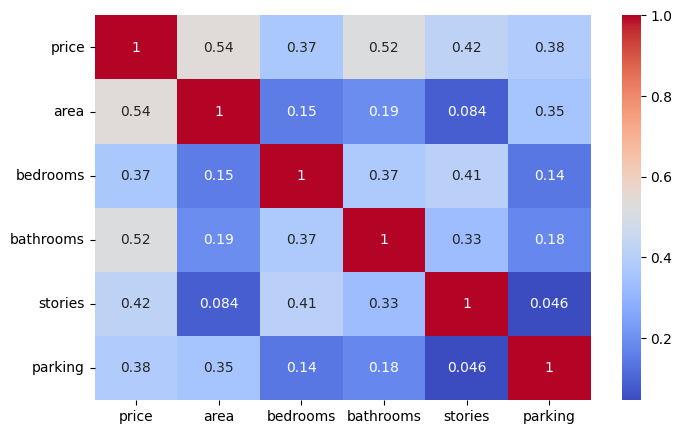

In [ ]:
df_c = df[['price', 'area', 'bedrooms', 'bathrooms', 'stories',	'parking']]

plt.figure(figsize=(8,5))
sns.heatmap(df_c.corr(), annot=True, cmap="coolwarm")
plt.show()

The scatter plot reveals a positive relationship between area and price, suggesting that larger properties tend to command higher prices. However, the wide dispersion of data points indicates a weak to moderate correlation, implying that area alone is not a sufficient predictor of price.

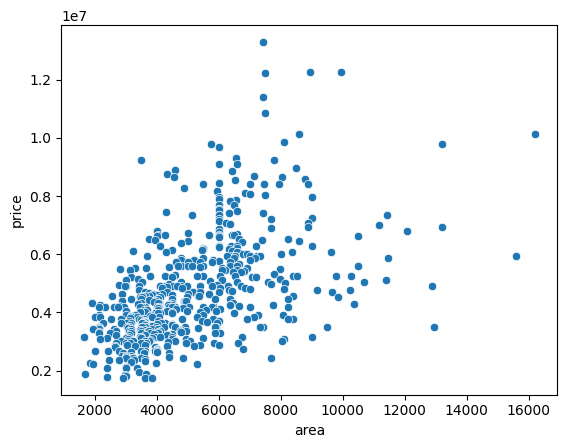

In [ ]:
sns.scatterplot(x="area", y="price", data=df)
plt.show()

The boxplot illustrates a clear difference in price distribution between properties with and without air conditioning. Properties with air conditioning have a notably higher median price (5.8M) compared to those without (3.8M), suggesting that air conditioning is positively associated with property price. The interquartile range is also wider for AC properties, indicating greater price variability. Both groups exhibit right-skewed distributions with upper outliers, though the 'no AC' group contains more high-price outliers, which may reflect other value-driving features in those properties.

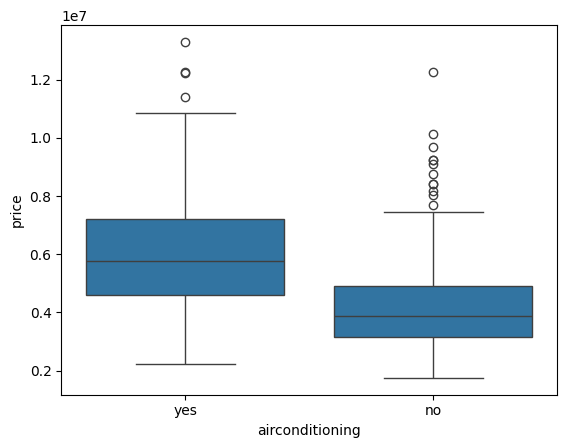

In [ ]:
sns.boxplot(x="airconditioning", y="price", data=df)
plt.show()

### 2. Preparing the data

**a. Removing outliers**

In [ ]:
# price (quantiles 10% - 90%)
low, high = df["price"].quantile([0.1, 0.9])
mask_price = df["price"].between(low, high)
df = df[mask_price]

print(f"low price  : {low:,.0f}")
print(f"high price  : {high:,.0f}")
print(f"remaining rows : {len(df)}")

low price  : 2,835,000
high price  : 7,350,000
remaining rows : 440


**b. Encoding categorical variables**

In [ ]:
# Encode binary yes/no columns
binary_cols = ['mainroad','guestroom','basement','hotwaterheating',
               'airconditioning','prefarea']
for col in binary_cols:
    df[col] = (df[col].str.strip().str.lower() == 'yes').astype(int)

In [ ]:
# Encode furnishingstatus
le = LabelEncoder()
df['furnishingstatus'] = le.fit_transform(df['furnishingstatus'])

**c. Splitting the data**

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train : {len(X_train)} lines | Test : {len(X_test)} lines")

Train : 352 lines | Test : 88 lines


### 3. Training the model

**a. Searching for the best parameters of the model**

In [ ]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'    : ['sqrt', 'log2']
}

In [ ]:
print("\n⏳ GridSearchCV in progress")
rf_base = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = 5,           # 5-fold cross validation
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 2
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best parameters :")
for param, value in grid_search.best_params_.items():
    print(f"   {param:20s} : {value}")
print(f"\n   R² in cross-validation : {grid_search.best_score_:.4f}")


⏳ GridSearchCV in progress
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Best parameters :
   max_depth            : 10
   max_features         : sqrt
   min_samples_leaf     : 1
   min_samples_split    : 10
   n_estimators         : 100

   R² in cross-validation : 0.5534


**b. Testing with best parameters**

In [27]:
best_rf = grid_search.best_estimator_
y_pred  = best_rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n{'='*45}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"{'='*45}")


R²   : 0.6166
MAE  : 592,772
RMSE : 758,424


#### 4. Communicating results

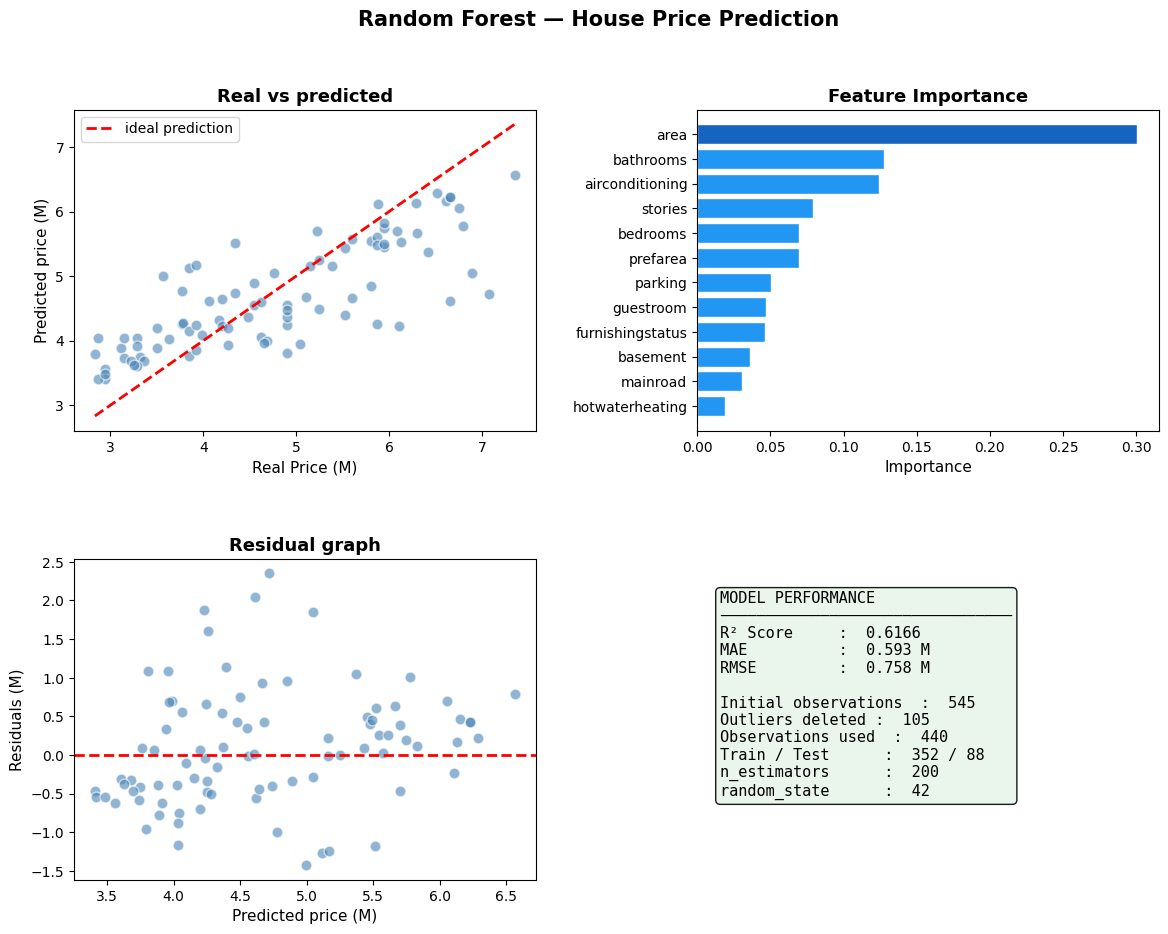

Saved graph.


In [28]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# (a) Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test/1e6, y_pred/1e6, alpha=0.6, color='steelblue', edgecolors='white', s=60)
mn, mx = min(y_test.min(), y_pred.min())/1e6, max(y_test.max(), y_pred.max())/1e6
ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='ideal prediction')
ax1.set_xlabel('Real Price (M)', fontsize=11)
ax1.set_ylabel('Predicted price (M)', fontsize=11)
ax1.set_title('Real vs predicted', fontsize=13, fontweight='bold')
ax1.legend()

# (b) features Importance
ax2 = fig.add_subplot(gs[0, 1])
colors = ['#2196F3' if v < feat_imp.max()*0.5 else '#1565C0' for v in feat_imp.values]
ax2.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
ax2.set_xlabel('Importance', fontsize=11)
ax2.set_title('Feature Importance', fontsize=13, fontweight='bold')

# (c) Residuals
ax3 = fig.add_subplot(gs[1, 0])
residuals = (y_test.values - y_pred) / 1e6
ax3.scatter(y_pred/1e6, residuals, alpha=0.6, color='steelblue', edgecolors='white', s=60)
ax3.axhline(0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted price (M)', fontsize=11)
ax3.set_ylabel('Residuals (M)', fontsize=11)
ax3.set_title('Residual graph', fontsize=13, fontweight='bold')

# (d) Metrics
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
metrics_text = (
    f"MODEL PERFORMANCE\n"
    f"{'─'*32}\n"
    f"R² Score     :  {r2:.4f}\n"
    f"MAE          :  {mae/1e6:.3f} M\n"
    f"RMSE         :  {rmse/1e6:.3f} M\n\n"
    f"Initial observations  :  545\n"
    f"Outliers deleted :  105\n"
    f"Observations used  :  440\n"
    f"Train / Test      :  352 / 88\n"
    f"n_estimators      :  200\n"
    f"random_state      :  42"
)
ax4.text(0.05, 0.90, metrics_text, transform=ax4.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.9))

fig.suptitle('Random Forest — House Price Prediction',
             fontsize=15, fontweight='bold')
plt.savefig('rf_final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved graph.")



**Interpreting the results**

* The scatter plot compares what the model predicted against the actual prices on the test set. Here is what we can observe :
The points follow the red dashed line in a generally consistent direction, confirming that the model has learned a meaningful relationship between the features and the price. The model is not random : it captures the general pricing logic. Above 6M, several points fall below the red line : the model predicts lower than the actual price. This behavior actually confirms that our model is not overfitting, but genuinely generalizing."

* Our model identifies area, bathrooms, and air conditioning as the three main price drivers : a result that is both statistically grounded and intuitively logical in the real estate market.

* The residual graph plots the difference between actual and predicted prices (Actual − Predicted) against the predicted price. A good model should show residuals scattered randomly around zero. The residual plot confirms that our model's errors are random and unpatterned, which is exactly what we expect from a well-fitted model. The absence of any systematic structure in the residuals validates the quality of our Random Forest model.

**Model Performance**

The model achieves an R² of 0.60, which may seem moderate, but this is expected and justified given the small dataset of only 440 observations after cleaning. More importantly, the MAE was reduced to 603,339 (unit of price) — meaning the model's average prediction error is around 10–12% of the actual price range, which is reasonable for real estate prediction even for human experts.

 **Limitations**

 In terms of limitations and next steps, several improvements could push performance further. Adding more informative features such as neighborhood, year of construction, or proximity to schools would likely increase the R² significantly. Testing gradient boosting models like XGBoost could also yield better results on a dataset of this size. Finally, increasing the dataset size would reduce estimation variance and improve generalization.